# Connecting to drive


In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


# Importing libraries

In [2]:
import os
import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder
from torch import nn, optim
import matplotlib.pyplot as plt

# Image transformations and loading

In [7]:

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [8]:
transform = transforms.Compose(
    [transforms.Grayscale(num_output_channels=1),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

In [9]:
train_data = ImageFolder('/content/drive/MyDrive/my_data/train', transform=transform)
#val_data = ImageFolder('/content/drive/MyDrive/fracture_dataset/val', transform=transform)
test_data = ImageFolder('/content/drive/MyDrive/my_data/test', transform=transform)

train_loader = DataLoader(train_data, batch_size=16, shuffle=True)
#val_loader = DataLoader(val_data, batch_size=32)
test_loader = DataLoader(test_data, batch_size=16)
print(train_data.classes)
print(train_data.class_to_idx)

print(test_data.classes)
print(test_data.class_to_idx)

['fractured', 'not fractured']
{'fractured': 0, 'not fractured': 1}
['fractured', 'not_fractured']
{'fractured': 0, 'not_fractured': 1}


In [5]:
from PIL import Image, ImageFile
import os

# Allowing loading truncated images
ImageFile.LOAD_TRUNCATED_IMAGES = True

# CNN architecture

In [11]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class FractureCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1) #one input channel, 16 feature maps
        self.pool = nn.MaxPool2d(2, 2) #kernel_size, stride
        self.fc1 = nn.Linear(16*112*112, 2)  #

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = torch.flatten(x, 1)
        x = F.softmax(self.fc1(x),dim=1)
        return x





# Training the network

In [4]:

def train(model, dataloader, optimizer, criterion):
    model.train()
    total_loss, correct = 0.0, 0
    for i, (inputs, labels) in enumerate(dataloader, 0):
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        correct += (outputs.argmax(1) == labels).sum().item()

    avg_loss = total_loss / len(dataloader)
    accuracy = 100 * correct / len(dataloader.dataset)
    print('Finished Training')
    return avg_loss, accuracy


def evaluate(model, dataloader, criterion):
    model.eval()  # Evaluation mode
    total_loss = 0.0
    correct = 0
    all_preds, all_labels = [], []

    with torch.no_grad():  # No gradient tracking
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, labels)

            total_loss += loss.item()
            correct += (outputs.argmax(1) == labels).sum().item()
            all_preds.extend(outputs.argmax(1).cpu().numpy())
            all_labels.extend(labels.cpu().numpy())


    avg_loss = total_loss / len(dataloader)
    accuracy = 100 * correct / len(dataloader.dataset)

    #print(f'Average Loss on Test Set: {avg_loss:.4f}')
    #print(f'Accuracy on Test Set: {accuracy:.2f}%')

    return avg_loss, accuracy, all_preds, all_labels


The next step is training the model:

In [12]:
import torch.optim as optim

#Initializing the model
model = FractureCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), 0.001) #Learning rate = 0.001


# ==== Training Loop ====
epochs = 10
train_loss, test_loss = [], []
train_acc, test_acc = [], []

for epoch in range(epochs):
    print(f"\n[Epoch {epoch+1}/{epochs}]")
    t_loss, t_acc = train(model, train_loader, optimizer, criterion)
    v_loss, v_acc, y_pred, y_true = evaluate(model, test_loader, criterion)

    train_loss.append(t_loss)
    test_loss.append(v_loss)
    train_acc.append(t_acc)
    test_acc.append(v_acc)

    print(f"Train Loss: {t_loss:.4f}, Train Acc: {t_acc:.2f}%")
    print(f"Test  Loss: {v_loss:.4f}, Test  Acc: {v_acc:.2f}%")
    print("-" * 50)


print("TRAINING COMPLETE")


[Epoch 1/10]
Finished Training
Train Loss: 0.7796, Train Acc: 49.78%
Test  Loss: 0.8133, Test  Acc: 50.00%
--------------------------------------------------

[Epoch 2/10]
Finished Training
Train Loss: 0.7716, Train Acc: 51.11%
Test  Loss: 0.8133, Test  Acc: 50.00%
--------------------------------------------------

[Epoch 3/10]
Finished Training
Train Loss: 0.7716, Train Acc: 51.11%
Test  Loss: 0.8133, Test  Acc: 50.00%
--------------------------------------------------

[Epoch 4/10]
Finished Training
Train Loss: 0.7716, Train Acc: 51.11%
Test  Loss: 0.8133, Test  Acc: 50.00%
--------------------------------------------------

[Epoch 5/10]
Finished Training
Train Loss: 0.8341, Train Acc: 51.11%
Test  Loss: 0.8133, Test  Acc: 50.00%
--------------------------------------------------

[Epoch 6/10]
Finished Training
Train Loss: 0.8341, Train Acc: 51.11%
Test  Loss: 0.8133, Test  Acc: 50.00%
--------------------------------------------------

[Epoch 7/10]
Finished Training
Train Loss: 0.

Model saved as fracture_cnn_model.pth


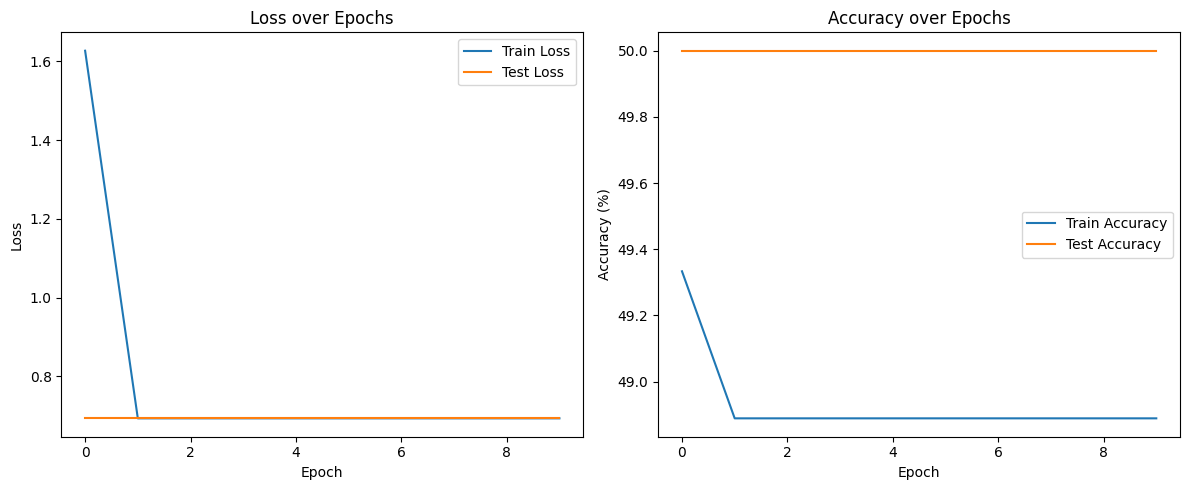

In [ ]:
# ==== Save Model ====
torch.save(model.state_dict(), "fracture_cnn_model.pth")
print("Model saved as fracture_cnn_model.pth")

# ==== Plot Loss ====
plt.figure(figsize=(12,5))
plt.subplot(1, 2, 1)
plt.plot(train_loss, label='Train Loss')
plt.plot(test_loss, label='Test Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss over Epochs")
plt.legend()

# ==== Plot Accuracy ====
plt.subplot(1, 2, 2)
plt.plot(train_acc, label='Train Accuracy')
plt.plot(test_acc, label='Test Accuracy')
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Accuracy over Epochs")
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
model = FractureCNN()
model.load_state_dict(torch.load('fracture_cnn_weights.pth'))
model.eval()  # Set to evaluation mode


FractureCNN(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=200704, out_features=2, bias=True)
)

dataiter = iter(test_loader)
images, labels = next(dataiter)


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)


FractureCNN(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=200704, out_features=2, bias=True)
)

In [ ]:
correct = 0
total = 0
all_preds = []
all_labels = []

with torch.no_grad():  # no need to compute gradients
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)                  # Forward pass
        _, predicted = torch.max(outputs, 1)     # Get index of highest score

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

accuracy = 100 * correct / total
print(f'Test Accuracy: {accuracy:.2f}%')


Test Accuracy: 52.08%
